# SNN-LOGS Decomposition: Sparse, Low-rank Identifiability Study
Following Chandrasekaran et. al. I wanted to see how the sparsity hyper-parameter in SNN-LOGS model can be determined from the decomposition. 

### Sum of Nuclear Norms - Latent Overlapping Group Sparsity (SNN-LOGS):

$$
\mathrm{min_{\mathcal{X}, \mathcal{S}}} \quad\quad \sum_{i=1}^N
\psi_i \|\mathbf{X}_{(i)}\|_* + \lambda \mathrm{inf}_{\mathcal{S} = \sum_g V_g} \|V_g\|_2
$$



# Grouping Experiment 1.A
This experiment tries to answer **G. Question 1.a** and tests Hypothesis 1

### **Control variables:**
- Low-rank part $\mathcal{X}$
    - dims = (100,50,24)
    - ranks = (5,5,5)
- Sparse part $\mathcal{S}$
    - Spatial graph: 10x10 Grid Graph
    - Spatial spread: isotropic
    - Spatial shape: constant
    - Radius = 2
    - Temporal duration  1
    - Number of anomalies = 250
- Algorithm Settings
    - $\psi_1=\psi_2=\psi_3$
    - `HoRPCA Singleton`
        - `rho` = `4*np.abs(Y).sum()/Y.size`
    - `SNN-LOGS(N1)`
        - Grouping: Neighbor r=1
        - Weighing: Squared group size
        - `rho_update` = `1`
        - `rho_update_threshold` = `100`
    - `SNN-LOGS(E)`
        - Grouping: Edge
        - Weighing: Squared group size ($\sqrt{2}$ for all groups)
        - maxit = 300
        - err_tol = 1e-6
        - `rho` = `4*np.abs(Y).sum()/Y.size`
        - `rho_update` = `1.1`
        - `rho_update_threshold` = `100`
    - `maxit` = `300`
    - `err_tol` = `1e-6`
    - `rho` = `4*np.abs(Y).sum()/Y.size`
- `resolution` = 51
- `eps` = 1/( `resolution` *20)
- `repeat` = 8

### **Independent variable**

- $\psi = (1-t)$
- $\lambda = t$
- $t \in$ `linspace(eps,1,resolution)`

### **Dependent variables**

- $\mathrm{diff}_\epsilon(t) = \|\hat{L}_{t-\epsilon} - \hat{L}_\epsilon\|_F + \|\hat{S}_{t-\epsilon} - \hat{S}_\epsilon\|_F$
- $\mathrm{tol}_\epsilon(t) = \frac{\|\hat{L}_t - L_\star\|_F}{\|L_\star\|_F} + \frac{\|\hat{S}_t - S_\star\|_F}{\|S_\star\|_F}$
- `AUC-ROC`
- `AUC-PRC`

In [2]:
%load_ext autoreload
%autoreload 2

from pprint import pprint
# from contextlib import nullcontext
from functools import partial
import os, sys

module_path = os.path.abspath(os.path.join('..','..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import networkx as nx
import mlflow
import optuna
import torch
import numpy as np
from sklearn.metrics import precision_recall_curve, auc, roc_curve
# from dask.distributed import Client, wait
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

# from src.proximal_ops.prox_overlapping_grouped_l21 import group_indicator_matrix
from src.models.horpca.horpca_torch import HoRPCA_Singleton
from src.models.lr_ssd.snn_logs import SNN_LOGS
from src.models.lr_ssd.snn__logn_gtv import SNN__LOGN_GTV
from src.multilinear_ops.t2m import t2m
# from src.models.lr_ssd.lr_logs_st_tf import LR_LOGS_ST_TF
from src.synthetic_data.generate_lr_data import generate_low_rank_data
from src.synthetic_data.generate_anomaly import generate_spatio_temporal_anomaly

import warnings
warnings.filterwarnings("ignore")
# torch.use_deterministic_algorithms(True)

from experiment_board.lr_sparse_identifiability_exps.exp1_scientist_utils import IdentifiabilityStudyExp1, experiment_1_runners, Experiment1Runner

In [4]:
resolution = 100
eps = 1/(resolution*20)
exp_runner = Experiment1Runner(
                *experiment_1_runners(
                    dim = (100,50,24),
                    ranks = (5,5,5),
                    graph_type = 'grid',
                    graph_dim = (10,10),
                    NoA = 1000,
                    local_dist = 'constant',
                    time_m = 3,
                    local_m = 1,
                    duration = 1,
                    amplitude = 0.25,
                    eps = eps,
                    lr_modes = [1,2,3],
                    err_tol = 1e-6,
                    maxit = 150,
                    rho_upd = 1,
                    rho_upd_thr = 100,
                    graph_modes = [1])
)

Exp = IdentifiabilityStudyExp1(exp_name='Exp_1A_demo3',
                         ExperimentRunner=exp_runner,
                         variables_of_interest=[
                            'spread', 'amplitude', 'radius'
                            ],
                           optuna_storage='sqlite:///identifiability_study.db'
                         )

# Exp.execute('1a', resolution=40, n_repeat=1, seed_start=1)
# Exp.study.optimize(Exp.experiment_runner, n_trials=137, n_jobs=4, show_progress_bar=True)
# Exp.delete_study()

[I 2024-12-07 20:22:44,764] Using an existing study with name 'Exp_1A_demo3' instead of creating a new one.


In [5]:
df = Exp.study.trials_dataframe()
for col_name in df.columns:
    if col_name.startswith('params_'):
        df.rename(columns={col_name:col_name.replace('params_','')}, inplace=True)
    if col_name.startswith('values_'):
        df.rename(columns={col_name:col_name.replace('values_','')}, inplace=True)
    if col_name.startswith('user_attrs_'):
        df.rename(columns={col_name:col_name.replace('user_attrs_','')}, inplace=True)
# df.interpolate(inplace=True)
df.columns
df['S_F/S_1'] = (df['S_fro']/df['S1']).fillna(0)
df['(S_F/S_1)_eps'] = (df['S_fro_eps']/df['S1_eps']).fillna(0)
df['(S_F/S_1)_diff'] = df['(S_F/S_1)_eps']-df['S_F/S_1']
df['L_F/L_nuc'] = (df['L_fro']/df['L_nuc_1']).fillna(0)
df['(L_F/L_nuc)_eps'] = (df['L_fro_eps']/df['L_nuc_1_eps']).fillna(0)
df['(L_F/L_nuc)_diff'] = df['(L_F/L_nuc)_eps']-df['L_F/L_nuc']
df['(S_F.L_f)/(S_1.L_nuc)'] = df['L_F/L_nuc']*df['S_F/S_1']

Algorithm: SNN_LOGS(N1) - t: 0.08795625000000001
Algorithm: SNN_LOGS(-E) - t: 0.1254375
Algorithm: HoRPCA - t: 0.37531250000000005


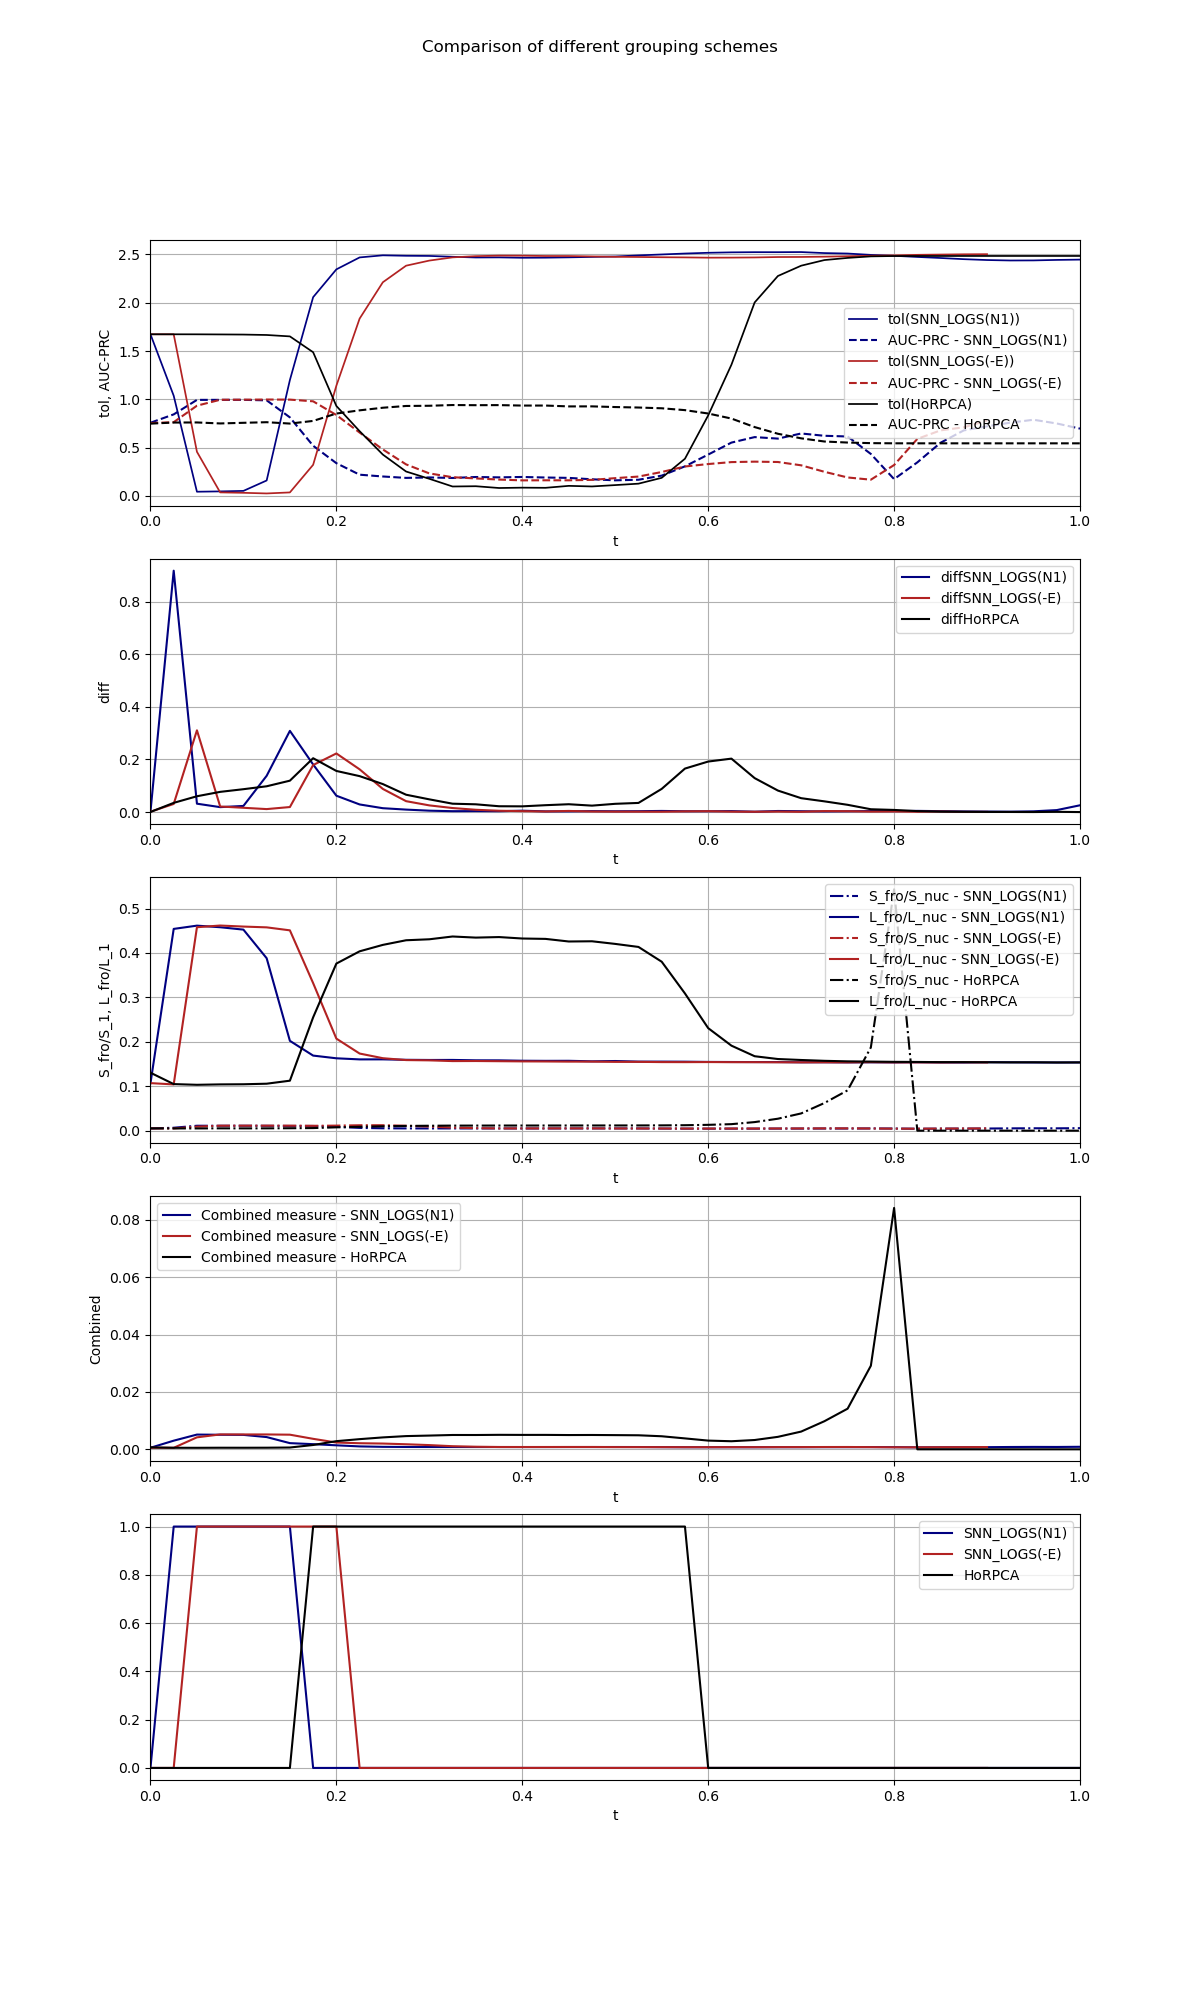

In [6]:
%matplotlib widget
def plot_grouping_comparison(df, figsize=(12,20)):
    model_dfs = {'SNN_LOGS(N1)': df[df['model']=='SNN_LOGS(N1)'],
                 'SNN_LOGS(-E)': df[df['model']=='SNN_LOGS(-E)'],
                 'HoRPCA': df[df['model']=='HoRPCA']}
    model_colors = {'SNN_LOGS(N1)': 'navy',
                    'SNN_LOGS(-E)': 'firebrick',
                    'HoRPCA': 'black'}
    fig, axe = plt.subplots(5,1, figsize=figsize)

    fig.suptitle('Comparison of different grouping schemes')
    axe[0].set_ylabel('tol, AUC-PRC')
    axe[1].set_ylabel('diff')
    axe[2].set_ylabel('S_fro/S_1, L_fro/L_1')
    axe[3].set_ylabel('Combined')

    for ax in axe.flatten():
        ax.set_xlabel('t')
        ax.grid(True)
        # ax.set_xlim(0,1)

    # axe[0].vlines(1/11, 0, 2.5, color='k', linestyle='-',linewidth=2.5, label=r'Default $\lambda$')
    # axe[0].set_ylim(0,2.5)
    # axe[1].set_ylim(0,1)
    for name, df_ in model_dfs.items():
        axe[0].plot(df_['t'], df_['tol'], label='tol('+name+')', color=model_colors[name], linestyle='-',linewidth=1.25)
        axe[0].plot(df_['t'], df_['AUC-PRC'], label='AUC-PRC - '+name, color=model_colors[name], linestyle='--',linewidth=1.5)
        axe[1].plot(df_['t'], df_['diff'], label='diff'+name, color=model_colors[name], linestyle='-',linewidth=1.5)
        axe[2].plot(df_['t'], df_['S_F/S_1'], label='S_fro/S_nuc - '+name, color=model_colors[name], linestyle='-.',linewidth=1.5)
        axe[2].plot(df_['t'], df_['L_F/L_nuc'], label='L_fro/L_nuc - '+name, color=model_colors[name], linestyle='-',linewidth=1.5)
        axe[3].plot(df_['t'], df_['(S_F.L_f)/(S_1.L_nuc)'], label='Combined measure - '+name, color=model_colors[name], linestyle='-',linewidth=1.5)
        # axe[3].plot(df_['t'], df_['(S_F/S_1)_diff'].abs(), label='(S_F/S_1)_diff - '+name, color=model_colors[name], linestyle='-',linewidth=1.5)
        # axe[3].plot(df_['t'], df_['(L_F/L_nuc)_diff'].abs(), label='(L_F/L_nuc)_diff - '+name, color=model_colors[name], linestyle='--',linewidth=1.5)
        # axe[4].plot(df_['t'], (df_['t'] == df_['t'][(df_['S_F/S_1'] > df_['S_F/S_1'].mean())].median()) , label='S_fro/S_nuc - '+name, color=model_colors[name], linestyle='-.',linewidth=1.5)
        # t_select_s1 = print(name, df_['t'][(df_['S_F/S_1'] > df_['S_F/S_1'].mean())].median())
        axe[4].plot(df_['t'], (df_['L_F/L_nuc'] > df_['L_F/L_nuc'].mean()), label=name, color=model_colors[name], linestyle='-',linewidth=1.5)# (df_['S_F/S_1'] > df_['S_F/S_1'].mean()) &
        print(f"Algorithm: {name} - t: {df_['t'][(df_['L_F/L_nuc'] > df_['L_F/L_nuc'].mean())].median()}")
    [(ax.set_xlabel('t'), ax.legend(),ax.grid(True), ax.set_xlim(0,1)) for ax in axe.flatten()];

plot_grouping_comparison(df)

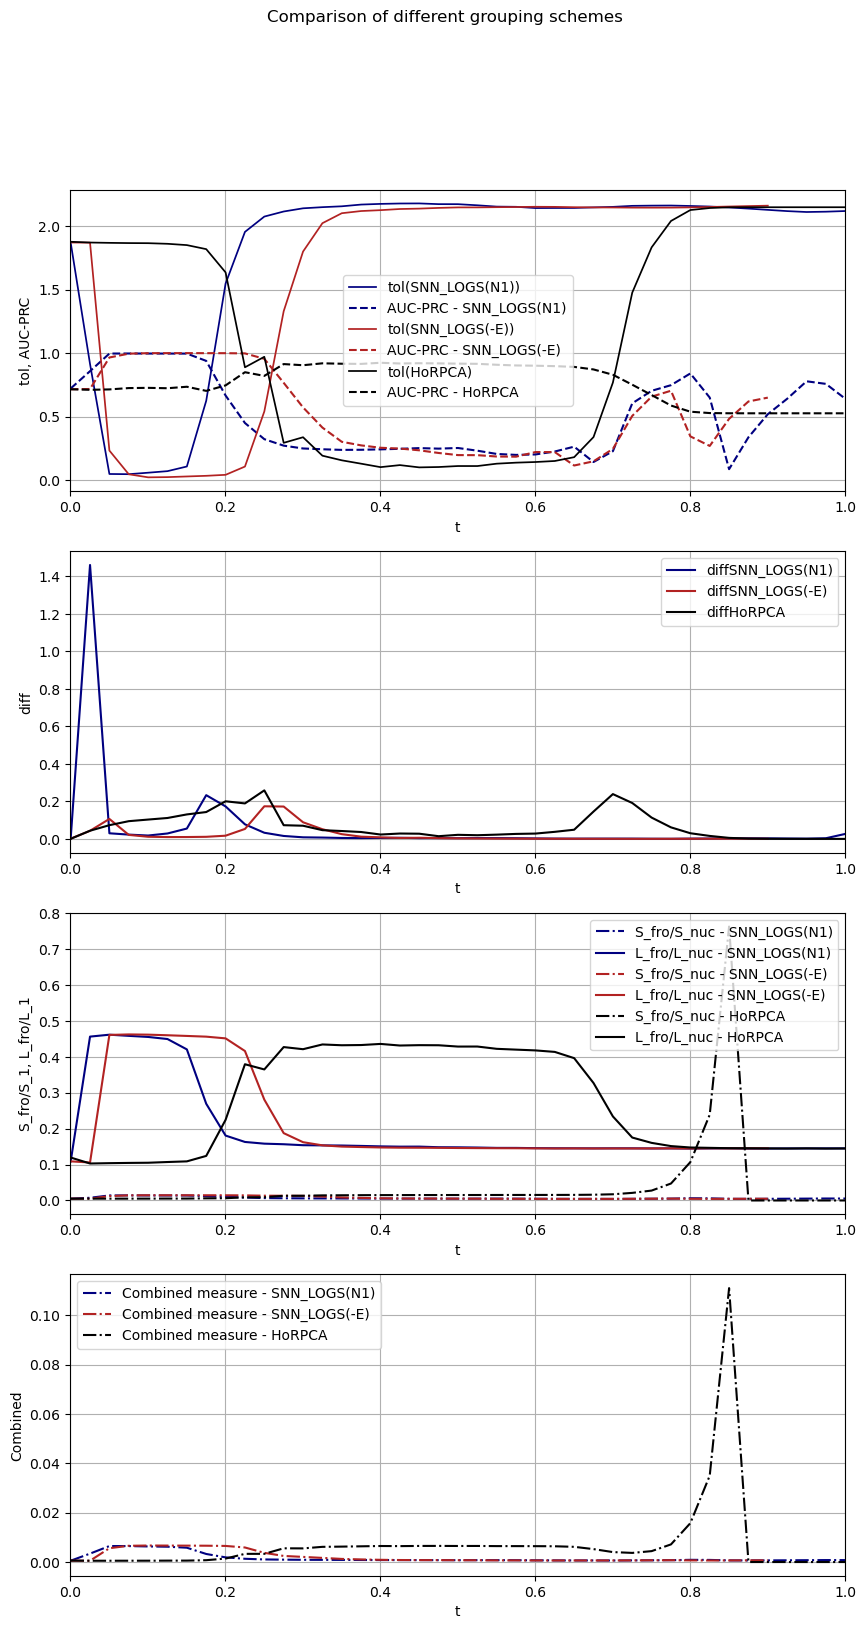

In [13]:
def plot_grouping_comparison(df, figsize=(10,18)):
    model_dfs = {'SNN_LOGS(N1)': df[df['model']=='SNN_LOGS(N1)'],
                 'SNN_LOGS(-E)': df[df['model']=='SNN_LOGS(-E)'],
                 'HoRPCA': df[df['model']=='HoRPCA']}
    model_colors = {'SNN_LOGS(N1)': 'navy',
                    'SNN_LOGS(-E)': 'firebrick',
                    'HoRPCA': 'black'}
    fig, axe = plt.subplots(4,1, figsize=figsize)

    fig.suptitle('Comparison of different grouping schemes')
    axe[0].set_ylabel('tol, AUC-PRC')
    axe[1].set_ylabel('diff')
    # axe[2].set_ylabel('AUC Scores')
    # axe[0].set_ylabel('S_fro/S_nuc')
    axe[2].set_ylabel('S_fro/S_1, L_fro/L_1')
    # axe[2].set_ylabel('nonzero_S')
    # axe[2].set_ylabel('L_fro/L_nuc')
    # axe[1].set_ylabel('L_fro/L_1')
    axe[3].set_ylabel('Combined')

    for ax in axe.flatten():
        ax.set_xlabel('t')
        ax.grid(True)
        # ax.set_xlim(0,1)

    # axe[0].vlines(1/11, 0, 2.5, color='k', linestyle='-',linewidth=2.5, label=r'Default $\lambda$')
    # axe[0].set_ylim(0,2.5)
    # axe[1].set_ylim(0,1)
    for name, df_ in model_dfs.items():
        axe[0].plot(df_['t'], df_['tol'], label='tol('+name+')', color=model_colors[name], linestyle='-',linewidth=1.25)
        axe[0].plot(df_['t'], df_['AUC-PRC'], label='AUC-PRC - '+name, color=model_colors[name], linestyle='--',linewidth=1.5)
        axe[1].plot(df_['t'], df_['diff'], label='diff'+name, color=model_colors[name], linestyle='-',linewidth=1.5)
        axe[2].plot(df_['t'], df_['S_F/S_1'], label='S_fro/S_nuc - '+name, color=model_colors[name], linestyle='-.',linewidth=1.5)
        axe[2].plot(df_['t'], df_['L_F/L_nuc'], label='L_fro/L_nuc - '+name, color=model_colors[name], linestyle='-',linewidth=1.5)
        axe[3].plot(df_['t'], df_['(S_F.L_f)/(S_1.L_nuc)'], label='Combined measure - '+name, color=model_colors[name], linestyle='-.',linewidth=1.5)
        # axe[2].plot(df_['t'], df_['L_F/L_nuc'], label='L_fro/L_nuc - '+name, color=model_colors[name], linestyle='--',linewidth=1.5)
        # axe[2,1].plot(df_['t'], df_['nonzero_S']/(100*50*24), label='S_sparsity'+name, color=model_colors[name], linestyle='-',linewidth=1.5)
        # axe[0,2].plot(df_['t'], df_['L_fro']/df_['L_nuc_1'], label='L_fro/L_nuc'+name, color=model_colors[name], linestyle='-',linewidth=1.5)
        # axe[1,2].plot(df_['t'], df_['L_fro']/df_['L1'], label='L_fro/L1'+name, color=model_colors[name], linestyle='-',linewidth=1.5)
        # axe[2,2].plot(df_['t'], df_['nonzero_L']/(100*50*24), label='L_sparsity'+name, color=model_colors[name], linestyle='-',linewidth=1.5)
        # axe[2,2].plot(df_['t'], (df_['ranks_S1']/(100)+df_['ranks_S2']/(50)+df_['ranks_S3']/(24))/3, label='ranks'+name, color=model_colors[name], linestyle='-',linewidth=1.5)
        # axe[2,2].plot(df_['t'], (df_['ranks_L1']/(100)+df_['ranks_l2']/(50)+df_['ranks_l3']/(24))/3, label='ranks'+name, color=model_colors[name], linestyle='-',linewidth=1.5)
        # if name is not 'HoRPCA':
        #     axe[3,0].plot(df_['t'], df_['L_fro']*df_['S_fro']/(df_['L_nuc_1']*df_['S1']), label='combined'+name, color=model_colors[name], linestyle='-',linewidth=1.5)
        
        # axe[0].plot(df_['t'], df_['tol'], label='tol('+name+')', color=model_colors[name], linestyle='-',linewidth=1.5)
        # axe[1].plot(df_['t'], 3*df_['diff'], label='diff('+name+')', color=model_colors[name], linestyle='-',linewidth=1.5)
        # # axe[1].vlines([cluster_points[model][0,0], cluster_points[model][1,0]], 0, 1, color=model_colors[name], linestyle='--',linewidth=3, label=name+'_cc')
        # axe[1].scatter(cluster_points[name][:,0], cluster_points[name][:,1], color=model_colors[name], label=name+'_cc')
        # axe[2].plot(df_['t'], df_['AUC-PRC'], label='AUC-PRC('+name+')', color=model_colors[name], linestyle='--',linewidth=1.5)
        # axe[2].plot(df_['t'], df_['AUC-ROC'], label='AUC-ROC('+name+')', color=model_colors[name], linestyle='-',linewidth=1.5)

    [(ax.set_xlabel('t'), ax.legend(),ax.grid(True), ax.set_xlim(0,1)) for ax in axe.flatten()];

plot_grouping_comparison(df)

In [1]:
from pprint import pprint
# from contextlib import nullcontext
from functools import partial
import os, sys

module_path = os.path.abspath(os.path.join('..','..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import networkx as nx
import mlflow
import optuna
import torch
import numpy as np
from sklearn.metrics import precision_recall_curve, auc, roc_curve
from dask.distributed import Client, wait
import matplotlib.pyplot as plt

# from src.proximal_ops.prox_overlapping_grouped_l21 import group_indicator_matrix
from src.models.horpca.horpca_torch import HoRPCA_Singleton
from src.models.lr_ssd.snn_logs import SNN_LOGS
# from src.models.lr_ssd.lr_logs_st_tf import LR_LOGS_ST_TF
from src.synthetic_data.generate_lr_data import generate_low_rank_data
from src.synthetic_data.generate_anomaly import generate_spatio_temporal_anomaly

import warnings
warnings.filterwarnings("ignore")
# torch.use_deterministic_algorithms(True)

In [2]:
from experiment_board.lr_sparse_identifiability_exps.synthetic_identifiability_study_utils import IdentifiabilityStudy

DATA_CONTROL_VARS = {
    'lr_param': {'dim': (100,50,24), 'ranks': (5,5,5)},
    'graph_settings':{'graph_type': 'grid', 'dim': (10,10)},
#                   :{'graph_type': 'Gnm', 'n': n, 'm': m, 'directed': False},
#                   :{'graph_type': 'Gnm', 'n': n, 'm': m, 'directed': True},
#                   :{'graph_type': 'random_regular', 'd': d, 'n': n},             
    'anomaly_param' : {'NoA': 250,
                        'amplitude':0.5,
                        'local_dist': 'constant', 
                        'time_m': 3, 'local_m': 1, 
                        'duration': 1, 'radius': 2, 
                        'spread': 'isotropic'},
}
err_tol = 1e-6
max_it = 200
rho_update_thr = 100
rho_update = 1
lr_modes = [1,2,3]
MODEL_CONTROL_VARS = {
    'HoRPCA': {'model_select' : {
                    'name': 'HoRPCA',
                    'lr_modes':lr_modes,
                    'verbose':0, 
                    'mu':rho_update_thr, 
                    'step_size_growth':rho_update,
                    'maxit': max_it,
                    'err_tol':err_tol,
                    },
                'model_param' : {}
    },
    'SNN_LOGS-N1': {
        'model_select' : {
            'name': 'SNN_LOGS',
            'lr_modes':lr_modes, 
            'graph_modes':[1],
            'grouping':'neighbor',
            'weighing':'size_normalized',
            'verbose':0,
            'r_hop':1
            },
        'model_param' : {# 'psis': [0.1, 0.1, 0.1], 'lda': 0.1, 
            'rho_update':rho_update, 
            'rho_update_thr':rho_update_thr, 
            'maxit':max_it, 
            'err_tol':err_tol,
            },
    },
    'SNN_LOGS-E': {
        'model_select' : {
            'name': 'SNN_LOGS',
            'lr_modes':lr_modes,
            'graph_modes':[1],
            'grouping':'edge',
            'weighing':'size_normalized',
            'verbose':0,
            'r_hop':1
            },
        'model_param' : {# 'psis': [0.1, 0.1, 0.1], 'lda': 0.1, 
            'rho_update':rho_update,
            'rho_update_thr':rho_update_thr, 
            'maxit':max_it,
            'err_tol':err_tol,
            }
    }
}

exp1_description = """
# Grouping Experiment 1.A
This experiment tries to answer **G. Question 1.a** and tests Hypothesis 1

### **Control variables:**
- Low-rank part $\mathcal{X}$
    - dims = (100,50,24)
    - ranks = (5,5,5)
- Sparse part $\mathcal{S}$
    - Spatial graph: 10x10 Grid Graph
    - Spatial spread: isotropic
    - Spatial shape: constant
    - Radius = 2
    - Temporal duration  1
    - Number of anomalies = 250
- Algorithm Settings
    - $\psi_1=\psi_2=\psi_3$
    - `HoRPCA Singleton`
        - `rho` = `4*np.abs(Y).sum()/Y.size`
    - `SNN-LOGS(N1)`
        - Grouping: Neighbor r=1
        - Weighing: Squared group size
        - `rho_update` = `1.1`
        - `rho_update_threshold` = `100`
    - `SNN-LOGS(E)`
        - Grouping: Edge
        - Weighing: Squared group size ($\sqrt{2}$ for all groups)
        - maxit = 300
        - err_tol = 1e-6
        - `rho` = `4*np.abs(Y).sum()/Y.size`
        - `rho_update` = `1.1`
        - `rho_update_threshold` = `100`
    - `maxit` = `300`
    - `err_tol` = `1e-6`
    - `rho` = `4*np.abs(Y).sum()/Y.size`
- `resolution` = 51
- `eps` = 1/( `resolution` *10)
- `repeat` = 8

### **Independent variable**

- $\psi = (1-t)$
- $\lambda = t$
- $t \in$ `linspace(eps,1,resolution)`

### **Dependent variables**

- $\mathrm{diff}_\epsilon(t) = \|\hat{L}_{t-\epsilon} - \hat{L}_\epsilon\|_F + \|\hat{S}_{t-\epsilon} - \hat{S}_\epsilon\|_F$
- $\mathrm{tol}_\epsilon(t) = \frac{\|\hat{L}_t - L_\star\|_F}{\|L_\star\|_F} + \frac{\|\hat{S}_t - S_\star\|_F}{\|S_\star\|_F}$
- `AUC-ROC`
- `AUC-PRC`
"""

In [4]:
print(f"Number of available CUDA devices: {torch.cuda.device_count()}")
client = Client(n_workers=5)
client

Number of available CUDA devices: 4


2024-11-19 06:11:14,105 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-vmidfels', purging
2024-11-19 06:11:14,105 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-4vzt0p0w', purging
2024-11-19 06:11:14,105 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-_khjq4lr', purging
2024-11-19 06:11:14,105 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-9sri3okt', purging
2024-11-19 06:11:14,105 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-worker-space/worker-7q6ydhzi', purging


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 5
Total threads: 50,Total memory: 187.32 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38021,Workers: 5
Dashboard: http://127.0.0.1:8787/status,Total threads: 50
Started: Just now,Total memory: 187.32 GiB
Comm: tcp://127.0.0.1:34989,Total threads: 10
Dashboard: http://127.0.0.1:35859/status,Memory: 37.46 GiB
Nanny: tcp://127.0.0.1:43275,


In [5]:
from torch.utils.tensorboard import SummaryWriter
exp1_name = 'SNN_LOGS_Id_Exp1A'
uri = 'http://127.0.0.1:8080'
devices = [f'cuda:{i}' for i in range(torch.cuda.device_count())]
id_study = IdentifiabilityStudy(exp1_name, exp1_description)
writer = SummaryWriter('./results/'+id_study.experiment_name)
results = id_study.experiment_1(repeat=4, 
                                resolution=25, 
                                data_control_vars=DATA_CONTROL_VARS,
                                mlflow_uri=uri,
                                model_control_vars=MODEL_CONTROL_VARS, 
                                devices=devices, 
                                eps=0.001,
                                client=client,
                                writer=writer)

Model HoRPCA: 25it [01:44,  4.18s/it]
Model SNN_LOGS-N1: 25it [02:01,  4.85s/it]
Model SNN_LOGS-E: 25it [01:53,  4.55s/it]


# Experiment 1:
Control variables:
- Low-rank part:
    - dims = (100,50,50)
    - ranks = (5,5,5)
- Sparse part:
    - Graph type: 10x10 Grid Graph
    - duration = 1
    - noa = 250
    - radius = 0
- Algorithm Settings:
    - SSN-LOGS
        - Grouping: Neighbor r=1
        - Weighing: Inverse weighed
        - maxit = 300
        - err_tol = 1e-6

Independent variable:
- $t$ in `linspace(eps,1,26)`

Dependent variables:
- $\mathrm{diff}_\epsilon(t) = \|\hat{L}_{t-\epsilon} - \hat{L}_\epsilon\|_F + \|\hat{S}_{t-\epsilon} - \hat{S}_\epsilon\|_F $
- $\mathrm{tol}_\epsilon(t) = \frac{\|\hat{L}_t - L_\star\|_F}{\|L_\star\|_F} + \frac{\|\hat{S}_t - S_\star\|_F}{\|S_\star\|_F}$
- `AUC-ROC`
- `AUC-PRC`

In [12]:
from tqdm import tqdm
import pandas as pd
err_tol = 1e-6
verbose = 0
rho_upd = 1
max_iter = 300
eps = 0.0005
t_steps = 51
t_range = np.linspace(eps, 1, t_steps, endpoint=True)
rho = 4*np.abs(Y).sum()/Y.size

metrics={'HoRPCA':[],'SNN-LOGS(N1)':[],'SNN-LOGS(E)':[]}
for i, t in tqdm(enumerate(t_range)):

    model = SNN_LOGS(Y, G, lr_modes=[1,2,3], graph_modes=[1],
                    grouping='neighbor', weighing='size_normalized',
                    verbose=0, device='cuda:1', r_hop=1)
    X,S = model([(1-t),(1-t),(1-t)], t, max_iter=max_iter, err_tol=err_tol, rho=rho,
                rho_update=1, rho_update_thr=100)
    
    model_eps =  SNN_LOGS(Y, G, lr_modes=[1,2,3], graph_modes=[1],
                    grouping='neighbor', weighing='size_normalized',
                    verbose=0, device='cuda:1', r_hop=1)
            
    X_eps, S_eps = model_eps([(1-t+eps),(1-t+eps),(1-t+eps)], t-eps, max_iter=300,
                             err_tol=err_tol, rho=rho,
                             rho_update=1, rho_update_thr=100)

    metric = calculate_metrics(model, model_eps, X_gt, S_gt, an_m)
    metrics['SNN-LOGS(N1)'].append(metric)

import pandas as pd
metrics['SNN-LOGS(N1)'] = pd.DataFrame(metrics['SNN-LOGS(N1)'])

51it [16:35, 19.53s/it]


NameError: name 'pd' is not defined

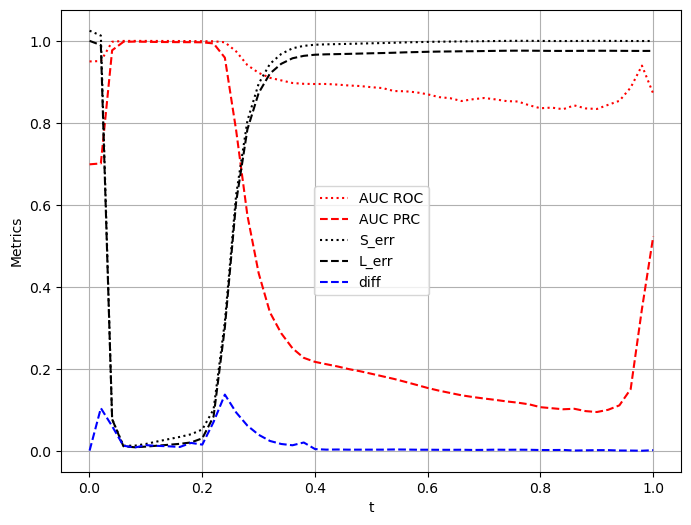

In [14]:
fig, axe = plt.subplots(1, 1, figsize=(8, 6))
axe.plot(t_range, metrics['SNN-LOGS(N1)']['AUC_ROC'], label='AUC ROC', color='r', linestyle=':')
axe.plot(t_range, metrics['SNN-LOGS(N1)']['AUC_PRC'], label='AUC PRC', color='r', linestyle='--')
axe.plot(t_range, metrics['SNN-LOGS(N1)']['S_relative_error'], label='S_err', color='k',linestyle=':')
axe.plot(t_range, metrics['SNN-LOGS(N1)']['X_relative_error'], label='L_err', color='k',linestyle='--')
axe.plot(t_range, metrics['SNN-LOGS(N1)']['diff'], label='diff', color='b',linestyle='--')
axe.set_xlabel('t')
axe.set_ylabel('Metrics')
axe.legend()
axe.grid()

In [15]:
from tqdm import tqdm
import pandas as pd
err_tol = 1e-6
verbose = 0
rho_upd = 1
max_iter = 300
eps = 0.0005
t_steps = 51
t_range = np.linspace(eps, 1, t_steps, endpoint=True)
rho = 4*np.abs(Y).sum()/Y.size


for i, t in tqdm(enumerate(t_range)):

    model = SNN_LOGS(Y, G, lr_modes=[1,2,3], graph_modes=[1],
                    grouping='edge', weighing='size_normalized',
                    verbose=0, device='cuda:1', r_hop=1)
    X,S = model([(1-t),(1-t),(1-t)], t, max_iter=max_iter, err_tol=err_tol, rho=rho,
                rho_update=1, rho_update_thr=100)
    
    model_eps =  SNN_LOGS(Y, G, lr_modes=[1,2,3], graph_modes=[1],
                    grouping='edge', weighing='size_normalized',
                    verbose=0, device='cuda:1', r_hop=1)
            
    X_eps, S_eps = model_eps([(1-t+eps),(1-t+eps),(1-t+eps)], t-eps, max_iter=300,
                             err_tol=err_tol, rho=rho,
                             rho_update=1, rho_update_thr=100)

    metric = calculate_metrics(model, model_eps, X_gt, S_gt, an_m)
    metrics['SNN-LOGS(E)'].append(metric)

import pandas as pd
metrics['SNN-LOGS(E)'] = pd.DataFrame(metrics['SNN-LOGS(E)'])

51it [30:44, 36.17s/it]


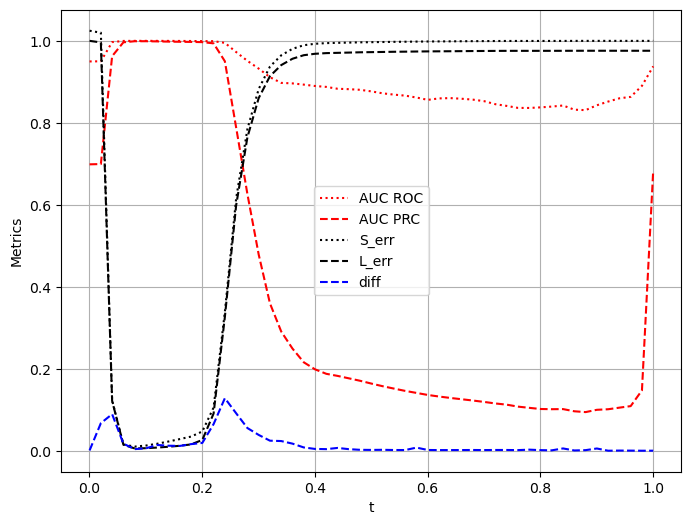

In [16]:
import pandas as pd
fig, axe = plt.subplots(1, 1, figsize=(8, 6))
axe.plot(t_range, metrics['SNN-LOGS(E)']['AUC_ROC'], label='AUC ROC', color='r', linestyle=':')
axe.plot(t_range, metrics['SNN-LOGS(E)']['AUC_PRC'], label='AUC PRC', color='r', linestyle='--')
axe.plot(t_range, metrics['SNN-LOGS(E)']['S_relative_error'], label='S_err', color='k',linestyle=':')
axe.plot(t_range, metrics['SNN-LOGS(E)']['X_relative_error'], label='L_err', color='k',linestyle='--')
axe.plot(t_range, metrics['SNN-LOGS(E)']['diff'], label='diff', color='b',linestyle='--')
axe.set_xlabel('t')
axe.set_ylabel('Metrics')
axe.legend()
axe.grid()


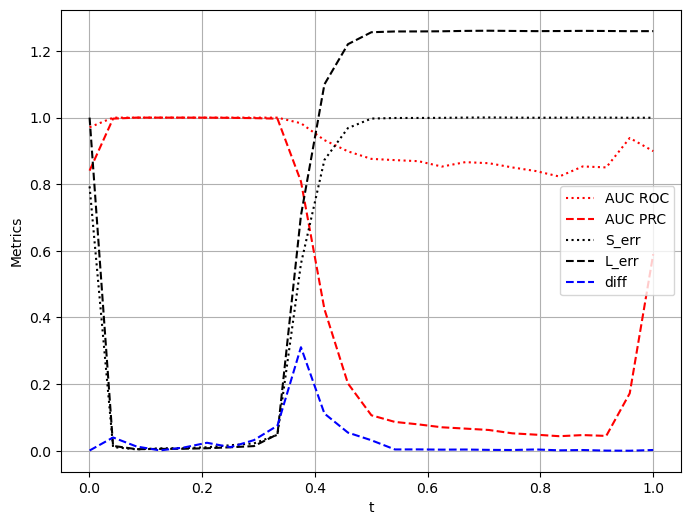

In [7]:
import pandas as pd
metrics_pd = pd.DataFrame(metrics)
fig, axe = plt.subplots(1, 1, figsize=(8, 6))
axe.plot(t_range, metrics_pd['AUC_ROC'], label='AUC ROC', color='r', linestyle=':')
axe.plot(t_range, metrics_pd['AUC_PRC'], label='AUC PRC', color='r', linestyle='--')
axe.plot(t_range, metrics_pd['S_relative_error'], label='S_err', color='k',linestyle=':')
axe.plot(t_range, metrics_pd['X_relative_error'], label='L_err', color='k',linestyle='--')
axe.plot(t_range, metrics_pd['diff'], label='diff', color='b',linestyle='--')
axe.set_xlabel('t')
axe.set_ylabel('Metrics')
axe.legend()
axe.grid()

save_path = f'./results/snn_logs_identifiability_study/Grid10x10_r0'
os.makedirs(save_path, exist_ok=True)
fig.savefig(f'{save_path}/metrics_vs_t.png')
metrics_pd.to_csv(f'{save_path}/metrics_vs_t.csv')


In [11]:
err_tol = 1e-6
verbose = 0
lda_f = 500
rho = 5
rho_upd = 1
max_iter = 300
eps = 0.001
t_steps = 25
t_range = np.linspace(eps, 1, t_steps, endpoint=True)
rho = 4*np.abs(Y).sum()/Y.size
params = {'lr_modes': [1,2,3],
            'max_iter': max_iter, 'err_tol': err_tol, 'step_size_growth': rho_upd,
            'device': 'cuda:2', 'verbose': False}


metrics2=[]
for i, t in tqdm(enumerate(t_range)):
    model = HoRPCA_Singleton(Y, 
                    lda_nucs=[(1-t),(1-t),(1-t)], lda1=t,
                    **params)
    X,S = model()
    
    model_eps =  HoRPCA_Singleton(Y,
                    lda_nucs=[(1-t+eps),(1-t+eps),(1-t+eps)], lda1=t-eps,
                    **params)
            
    X_eps, S_eps = model_eps()

    metric = calculate_metrics(model, model_eps, X_gt, S_gt, an_m)
    metrics2.append(metric)

25it [00:42,  1.72s/it]


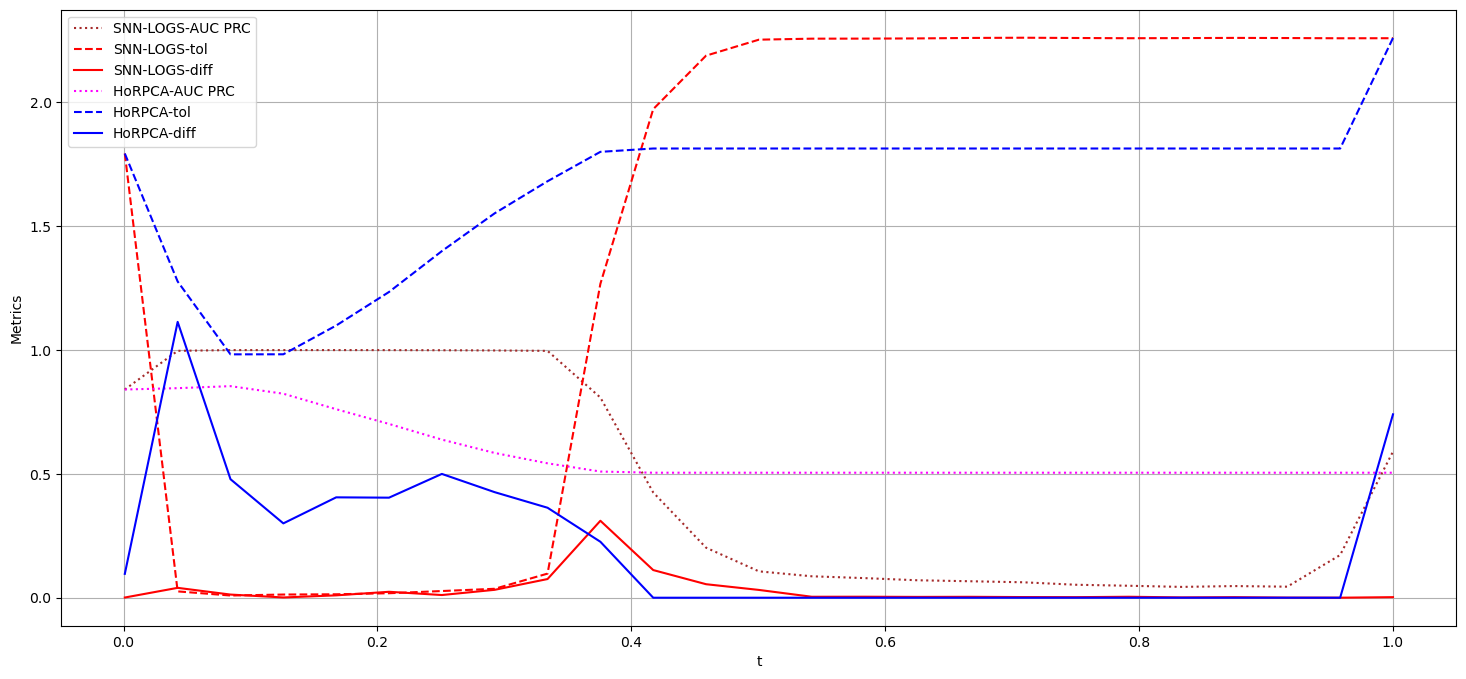

In [24]:
import pandas as pd
fig, axe = plt.subplots(1, 1, figsize=(18, 8))
names = ['SNN-LOGS', 'HoRPCA']
colors = [('red','brown'), ('blue','magenta')]
for i, metric in enumerate([metrics, metrics2]):
    metrics_pd = pd.DataFrame(metric)
    # axe.plot(t_range, metrics_pd['AUC_ROC'], label=names[i]+'-AUC ROC', color='r', linestyle=':')
    axe.plot(t_range, metrics_pd['AUC_PRC'], label=names[i]+'-AUC PRC', color=colors[i][1], linestyle=':')
    axe.plot(t_range, metrics_pd['X_relative_error']+metrics_pd['S_relative_error'], label=names[i]+'-tol', color=colors[i][0],linestyle='--')
    axe.plot(t_range, metrics_pd['diff'], label=names[i]+'-diff', color=colors[i][0],linestyle='-')
axe.set_xlabel('t')
axe.set_ylabel('Metrics')
axe.legend()
axe.grid()

save_path = f'./results/snn_logs_identifiability_study/Grid10x10_r0'
os.makedirs(save_path, exist_ok=True)
fig.savefig(f'{save_path}/metrics_vs_t.png')
metrics_pd.to_csv(f'{save_path}/metrics_vs_t.csv')

In [5]:
import optuna
from time import sleep

class Objective:
    def __init__(self, control_var):
        self.control_var = control_var

    def __call__(self, trial):
        x = trial.suggest_float('x', -5, 5)
        print(trial.user_attrs['device'])
        sleep(3)
        return (x - self.control_var) ** 2

objective = Objective(1)
study = optuna.create_study(direction='minimize')

for x in [-1, -0.5, 0, 0.98, 1.4]:
    study.enqueue_trial({'x': x}, {'device':'cuda:0'})

study.set_metric_names(['loss'])
study.optimize(objective, n_trials=5, n_jobs=2)

[I 2024-11-20 00:20:26,864] A new study created in memory with name: no-name-286cc593-2dda-4172-bd40-993c079895cb


/tmp/ipykernel_2917082/3259488164.py:20: ExperimentalWarning: set_metric_names is experimental (supported from v3.2.0). The interface can change in the future.
  study.set_metric_names(['loss'])


cuda:0
cuda:0


[I 2024-11-20 00:20:31,340] Trial 1 finished with value: {'loss': 2.25} and parameters: {'x': -0.5}. Best is trial 1 with value: 2.25.
[I 2024-11-20 00:20:31,342] Trial 0 finished with value: {'loss': 4.0} and parameters: {'x': -1.0}. Best is trial 1 with value: 2.25.


cuda:0cuda:0



[I 2024-11-20 00:20:34,379] Trial 3 finished with value: {'loss': 0.0004000000000000007} and parameters: {'x': 0.98}. Best is trial 3 with value: 0.0004000000000000007.
[I 2024-11-20 00:20:34,379] Trial 2 finished with value: {'loss': 1.0} and parameters: {'x': 0.0}. Best is trial 3 with value: 0.0004000000000000007.


cuda:0


[I 2024-11-20 00:20:37,383] Trial 4 finished with value: {'loss': 0.15999999999999992} and parameters: {'x': 1.4}. Best is trial 3 with value: 0.0004000000000000007.


In [1]:
import os, sys
module_path = os.path.abspath(os.path.join('..','..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from pprint import pprint
# from contextlib import nullcontext
from functools import partial

import numpy as np
from sklearn.metrics import precision_recall_curve, auc, roc_curve
import networkx as nx
import mlflow
import optuna
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

from src.models.horpca.horpca_torch import HoRPCA_Singleton
from src.models.lr_ssd.snn_logs import SNN_LOGS

from src.synthetic_data.generate_lr_data import generate_low_rank_data
from src.synthetic_data.generate_anomaly import generate_spatio_temporal_anomaly

class Objective:
    def __init__(self, 
                 data_ctr_var,   # Control variables for data generation 
                 model_selector, # Used to select the evaluated model
                 model_ctr_var,  # Used to set the control parameters of the model
                 ):
        """Initialize the objective function that will run the experiment

        Independent variables should be passed through the trial object
        as user attributes. Independent variables other than hyperparameters
        should be plotted externally. When you know the hyperparameters,
        consider using Ask-tell interface with dask client instead of
        relying on optuna study to parallelize the experiments.
        Args:
            data_ctr_var (dict): Control variables for data generation
            model_selector (dict): Model selection parameter
            model_ctr_var (dict): Model control variables
        """
        self.data_ctr_var = data_ctr_var
        self.model_selector = model_selector
        self.model_ctr_var = model_ctr_var

    def __call__(self, trial):
        # Select model/algorithm
        # Call algorithm function
        # Get the result
        if self.model_selector['model'] == 'HoRPCA':
            result = self.run_HoRPCA(trial)
        elif self.model_selector['model'] == 'SNN_LOGS':
            result = self.run_SNN_LOGS(trial)
        elif self.model_selector['model'] == 'SNN_LOGS+VR':
            result = self.run_SNN_LOGS_VR(trial)
        
        trial.set_user_attr('sparsity',(result[4]==0).sum().item())
        # Calculate metrics
        metrics = self.calculate_metrics(*result)
        
        # Log the metrics
        # ['tol', 'diff', 'S_err', 'L_err', 'AUC_PRC', 'AUC_ROC']
        return metrics['tol'], metrics['diff'], metrics['S_err'], metrics['L_err'], metrics['AUC_ROC'], metrics['AUC_PRC']

    def run_HoRPCA(self, trial):
        """model_ctr_var and model_selector should be like the following

        >>> model_ctr_var = {
            'eps': eps,
            'err_tol': err_tol,
            'maxit': max_iter,
            'step_size_growth': rho_upd,
            'mu': rho_upt_thr,
            'verbose':0,
            'lr_modes': lr_modes,
            }
        
        >>> model_selector = {'model': 'HoRPCA'}
        """
        # Generate data
        Y, X_gt, S_gt, labels, G = self.generate_data(trial)
        device = trial.user_attrs['device']
        
        # Ask for hyperparameter
        t = trial.suggest_float('t', 0, 1)
        
        # Create model
        eps = self.model_ctr_var['eps']
        model_ctr_var = self.model_ctr_var.copy()
        model_ctr_var['rho'] = model_ctr_var.get('rho', 4*np.abs(Y).sum()/Y.size)
        model1 = HoRPCA_Singleton(Y, 
                                  lda_nucs=[(1-t)]*len(model_ctr_var['lr_modes']),
                                  lda1=t,
                                  **model_ctr_var, device=device)
        
        model2 = HoRPCA_Singleton(Y, lda_nucs=[(1-t+eps),(1-t+eps),(1-t+eps)], lda1=t-eps, 
                                  **model_ctr_var, device=device)
        
        # Run the models
        X1, S1 = model1()
        X2, S2 = model2()

        # Return the model and the ground truth
        return model1, model2, X_gt, S_gt, labels

    def run_SNN_LOGS(self, trial):
        """model_ctr_var and model_selector should be like the following

        >>> model_selector = {
            'model': 'SNN_LOGS',
            'lr_modes': lr_modes,
            'graph_modes': graph_modes,
            'grouping':'neighbor',
            'weighing':'size_normalized',
            'verbose':0,
            'r_hop': r_hop}
        
        >>> model_ctr_var = {
            'eps': eps,
            'rho_update': rho_upd,
            'rho_update_thr': rho_upd_thr,
            'maxit': max_iter,
            'err_tol': err_tol,
            }
        """
        # Generate data
        Y, X_gt, S_gt, labels, G = self.generate_data(trial)
        device = trial.user_attrs['device']

        # Ask hyperparameters
        t = trial.suggest_float('t', 0, 1)

        # Create model
        eps = self.model_ctr_var['eps']
        model_ctr_var = self.model_ctr_var.copy()
        model_ctr_var['rho'] = model_ctr_var.get('rho', 4*np.abs(Y).sum()/Y.size)
        model1 = SNN_LOGS(Y, G,**self.model_selector, device=device)
        model2 = SNN_LOGS(Y, G,**self.model_selector, device=device)

        # Run the model
        X1, S1 = model1([(1-t)]*len(self.model_selector['lr_modes']),
                        t,
                        **model_ctr_var)
        X2, S2 = model2([(1-t+eps)]*len(self.model_selector['lr_modes']),
                        t-eps,
                        **model_ctr_var)

        return model1, model2, X_gt, S_gt, labels

    def run_SNN_LOGS_VR(self, trial):
        pass

    def generate_data(self, trial):
        """data_ctr_var should be like the following

        >>> data_ctr_var = {
            'lr_param': {
                'dim': dim,
                'ranks': ranks
                },
            'graph_settings': {
                'graph_type': graph_type,
                'dim': graph_dim
                },
            'anomaly_param': {
                'NoA': NoA,
                'local_dist': local_dist,
                'time_m': time_m,
                'local_m': local_m,
                'duration': duration,
                'radius': radius,
                'spread': anomaly_type, # 'isotropic' or 'anisotropic'
                'amplitude': amplitude}
            }
        """
        seed = trial.user_attrs['seed']
        lr_param = self.data_ctr_var['lr_param']
        # data_gen_param['lr_param'] = {'dim': [d1,d2,d3], 'ranks': [r1,r2,r3]}
        X_gt = generate_low_rank_data(**lr_param, seed=seed)
        
        graph_setting = self.data_ctr_var['graph_settings']
        # graph_setting = {'graph_type': 'grid', 'dim': (d1,d2)}
        #               = {'graph_type': 'Gnm', 'n': n, 'm': m, 'directed': False}
        #               = {'graph_type': 'Gnm', 'n': n, 'm': m, 'directed': True}
        #               = {'graph_type': 'random_regular', 'd': d, 'n': n}
        if graph_setting['graph_type'] == 'grid':
            G = nx.grid_2d_graph(*graph_setting['dim'], periodic=False)
        elif graph_setting['graph_type'] == 'Gnm':
            G = nx.gnm_random_graph(graph_setting['n'], graph_setting['m'], 
                                    directed=graph_setting['directed'], seed=graph_setting['seed'])
        elif graph_setting['graph_type'] == 'random_regular':
            G = nx.random_regular_graph(graph_setting['d'], graph_setting['n'],
                                        seed=graph_setting['seed'])
        else:
            raise ValueError("Invalid graph type.")

        anomaly_param = self.data_ctr_var['anomaly_param']
        # anomaly_param = {'NoA': NoA, 'local_dist': local_dist, 
        #               'time_m': time_m, 'local_m': local_m, 
        #               'duration': duration, 'radius': radius, 
        #               'spread': 'isotropic', 'amplitude': amplitude}
        S_gt, labels = generate_spatio_temporal_anomaly(X_gt.shape, G, 
                            anomaly_param['NoA'],
                            amplitude=anomaly_param['amplitude'],
                            local_dist=anomaly_param['local_dist'],
                            time_m=anomaly_param['time_m'], local_m=anomaly_param['local_m'],
                            duration=anomaly_param['duration'], radius=anomaly_param['radius'], 
                            anomaly_spread=anomaly_param['spread'], seed=seed)
        Y = X_gt + S_gt
        return Y, X_gt, S_gt, labels, G

        #           model1, model2, X_gt, S_gt, labels, G
    def calculate_metrics(self, model, model_eps, X_gt, S_gt, labels):
        device = model.device
        fpr, tpr, thresholds = roc_curve(labels.ravel(),
                                        torch.abs(model.S).ravel().cpu().numpy())
        precision, recall, thresholds = precision_recall_curve(labels.ravel(),
                                            torch.abs(model.S).ravel().cpu().numpy())
        auc_prc_score = auc(recall, precision)
        auc_roc_score = auc(fpr, tpr)

        metrics = {'AUC_ROC': auc_roc_score,
                    'AUC_PRC': auc_prc_score,
                    'S_diff': torch.norm(model.S-model_eps.S).cpu().numpy().item(),
                    'L_diff': torch.norm(model.X-model_eps.X).cpu().numpy().item(),
                    'S_err': (torch.norm(torch.tensor(S_gt, device=device)-model.S).cpu().numpy()/np.linalg.norm(S_gt)).item(),
                    'L_err': (torch.norm(torch.tensor(X_gt, device=device)-model.X).cpu().numpy()/np.linalg.norm(X_gt)).item()
                    }
        metrics['tol'] = metrics['S_err'] + metrics['L_err']
        metrics['diff'] = metrics['S_diff'] + metrics['L_diff']
        return metrics